# ARGUS-FEDER — Does a helium bubble layer change how tungsten survives a tokamak?

This notebook shows **ARGUS**, a notebook-native AI agent, working on a single
question. Questions are typed in plain English into a `%%ask` cell; the agent
decides what to look up, writes and runs its own code, and reports back.

## The question

A burning plasma makes helium. It is the ash of the fusion reaction, and it
arrives at the wall alongside the hydrogen isotopes that fuel it. Helium does
not simply stick to tungsten and stay there — at reactor-relevant temperatures
it clusters into nanometre bubbles a short distance below the surface, and in
time that layer restructures the surface entirely.

So the tungsten that faces a burning plasma is not the tungsten that was
installed. It is tungsten with a bubble layer already in it. The question this
raises is whether that layer changes what happens next:

- does the modified surface **erode** differently under plasma bombardment?
- does its **morphology** evolve differently?
- and does it **retain hydrogen isotopes** differently — the number that decides
  how much fuel a reactor holds in its walls?

The delivery this notebook works from was built to ask exactly that. Tungsten
coupons were pre-exposed to helium plasma in the PISCES-A linear device at two
temperatures, then mounted on the DiMES probe alongside coupons that had not
been, and all of them were exposed together to real DIII-D discharges — the
same shots, the same cap, the same plasma.

That design is what makes a comparison possible. What follows is an attempt to
carry it out, and an account of how far the delivered measurements actually
reach.


In [ ]:
%reset

# A. Assembling the dataset


## Q1 — What helium-modified tungsten is here, and what was done to it?

_Materials · data discovery · **answerable**_

Before any comparison, the experiment's structure has to be read rather than
assumed: which coupons saw helium, at what condition, which of those went on to
a tokamak, and which discharges they sat through.

**Expect:** the helium-modified coupons named, the pre-exposure conditions that
distinguish them, which ones continued to DIII-D and which stayed behind, and
the shot numbers each exposure carries.


In [1]:
%%ask --review
Which samples in this delivery were exposed to helium before anything else
happened to them, and what distinguishes one from another? Say which of them
went on to a plasma exposure in the tokamak, and which discharges those were.

I'll plan this task and start by consulting the materials skill.

Reading the materials skill instructions now.

Now reading the skill's Learnings.md, which exists for this skill.

The skill and its learnings are clear. Now I'll write an exploration script to see the delivery, samples, and exposure campaigns.

Six samples sat in the two PISCES He campaigns (slot "Exposure 1"). Now I'll pull the measured-quantity catalogue and per-sample observations to see what distinguishes them.

The structure is clear. Let me quickly confirm which samples hold the pre-exposure SEM morphology rows and the FASTCAM exposure rows (3 each) by checking the remaining three samples.

All data is in hand. Marking the analysis steps complete and writing the report.

I'll recompute all three ERDA brackets programmatically from the six samples' rows before restating them.

The recomputed He range runs 2.53–3.97×10¹⁵ atoms cm⁻²; the D (0.67–2.4×10¹⁵ over the four double-exposed) and H (1.07–1.79×10¹⁵) brackets verify as stated.

**The delivery** is `2026-09-04_amy` (from Amy, received 2026-09-04; 9 tungsten samples, investigator Greg Sinclair). In this delivery the first thing that happened to six of the nine samples was a helium plasma exposure: two PISCES campaigns in slot "Exposure 1" (2020-01-24 to 2020-01-27, coordinator Russ Doerner), both He at 70 eV impact energy, with no device attached — a linear-machine exposure, so no shot numbers exist for it. The other three samples (W-pristine, W-DH, W-DL) never saw helium first: W-pristine was never exposed at all, and W-DH/W-DL went straight to DIII-D.

**The six helium-first samples**

| Sample | He campaign | He exposure conditions | What followed |
|---|---|---|---|
| W-He800 | Exposure 1, 800 K | flux 2.83×10²² m⁻²s⁻¹, fluence 1.2×10²⁵ m⁻², 480 s | nothing further |
| W-He600 | Exposure 1, 600 K | flux 4.1×10²¹ m⁻²s⁻¹, fluence 1.0×10²⁵ m⁻², 4260 s | nothing further |
| W-He800-DH | Exposure 1, 800 K | same 800 K campaign as W-He800 | DIII-D H-mode |
| W-He600-DH | Exposure 1, 600 K | same 600 K campaign as W-He600 | DIII-D H-mode |
| W-He800-DL | Exposure 1, 800 K | same 800 K campaign as W-He800 | DIII-D L-mode |
| W-He600-DL | Exposure 1, 600 K | same 600 K campaign as W-He600 | DIII-D L-mode |

**What distinguishes one from another.** Everything else about them is held constant, so three things separate them:

1. **He exposure temperature** — 800 K vs 600 K, and the two campaigns differ in more than temperature: the 800 K campaign delivered its fluence at ~7× the flux over ~9× shorter a duration (1.2×10²⁵ m⁻² at 2.83×10²² m⁻²s⁻¹ for 480 s, vs 1.0×10²⁵ m⁻² at 4.1×10²¹ m⁻²s⁻¹ for 4260 s). These are two levels of the pre-treatment, not one.
2. **What came after the helium** — nothing (W-He800, W-He600), an H-mode DIII-D exposure (-DH), or an L-mode DIII-D exposure (-DL). This is the experiment's second factor.
3. **Post-exposure chemistry** — the two He-only samples end as "W-He" with zero retained D and H by ERDA; all four double-exposed samples end as "W-D-H-He", having picked up deuterium (ERDA D from 6.7×10¹⁴ to 2.4×10¹⁵ cm⁻²) and hydrogen (1.1×10¹⁵ to 1.8×10¹⁵ cm⁻²) alongside the helium. Every one of the six retains He (ERDA He 2.53×10¹⁵–3.97×10¹⁵ atoms cm⁻², i.e. up to ≈4.0×10¹⁵, with W-He600 the highest and W-He600-DH the lowest).

Everything else is common to all six: same material (W), same top-hat geometry (0.235 inch inner radius, 0.062 inch thick), same recrystallization (1373 K for 3600 s), perpendicular grain orientation. Note also that only W-He800 and W-He600 were among the three samples (with W-pristine) given pre-exposure SEM morphology records — the four that went on to DIII-D were not.

**Which went on to plasma in the tokamak, and the discharges.** Four of the six, all on 2021-03-15 (Exposure 2, coordinator Greg Sinclair), split by confinement regime:

- **H-mode** (exposure 19: D species, 0.72 MW m⁻², 150 eV, nₑ 5.76×10¹⁸ m⁻³, Tₑ 27.9 eV, 12.5 s): **W-He800-DH** and **W-He600-DH** — shots **185258, 185259, 185260, 185265, 185266** .
- **L-mode** (exposure 20: D species, 0.47 MW m⁻², 175 eV, nₑ 7.35×10¹⁸ m⁻³, Tₑ 40.8 eV, 10.0 s): **W-He800-DL** and **W-He600-DL** — shots **185261, 185262, 185263, 185264** .

W-He800 and W-He600 were retained as He-only references and saw no tokamak exposure.

## Q2 — Which of them have their bubble layer characterised?

_Materials · linking two stages · **answerable, but not coupon by coupon**_

The question in the introduction is about how the *initial* bubble layer
affects what follows, so the initial state has to be documented for whichever
coupons went into the tokamak. Imaging is the record of that state.

Asking for it per coupon is the obvious move and it is worth watching what
happens: an empty result would mean either that the characterisation was never
done, or that it is attached to something other than the coupon that was
exposed. Those are different conclusions and only one of them is a gap.

**Expect:** a clear statement of which coupons carry pre-exposure imaging in
their own right. If the exposed coupons do not, expect the answer to find
whatever does connect them to a characterised sample, to say what that
connection is, and to be explicit about what treating one as a stand-in for
the other assumes.


Skill and learnings read. Now I'll write an exploration script that pulls every observation stage and artifact attached to the four He-then-DIII-D samples, plus the full artifact catalogue and document mentions of SEM.

The catalogue answers half the question already: the four DH/DL samples carry **no** Morphology rows and **no** attached files, while 327 pre-characterization files hang off only W-He600, W-He800 and W-pristine. Now I need the content behind those records — the Morphology observation text, the availability sheet's per-sample status, the FIB-SEM reference docx, the exposure-1 info file, and acquisition metadata from image companions.

The tables confirm the story: only W-He800, W-He600 and W-pristine carry `Morphology` rows (SEM, pointing at `pre-characterization/SEM/<sample>/` files), and exposure-1 info lists identical He conditions for each DH/DL sample and its reference. The availability-sheet cell colours still need parsing — my styles parse crashed because I called `.iter` on a decoded string instead of an ElementTree element. Fixing that and adding a sweep of all 162 SEM companion files plus the proposal-document context.

The availability sheet's colour coding needs exact fillId comparison (theme strings alone can collapse distinct fills), and I still need the full sweep of all 162 SEM companion files plus the proposal context. Running both now.

The availability sheet decodes cleanly: pre-exposure "Morphology (SEM)" is marked **in-hand for all nine samples** , including the four DH/DL ones, while the delivered files cover only three coupons. Before writing up, I'll render one common-magnification (50 k×) surface image per imaged coupon as the visual stand-in. First, checking the `show_images` helper signature.

The figure is saved. One last check — whether any W-He800 50 k× capture ran at 10 kV like the other two coupons, so the figure's conditions are described accurately.

All checks done. Before the report: my `pre_tok_state2.py` had an edit-and-retry cycle (crashed feeding a decoded string to `.iter()`), so I'm recording that fix in the skill's Learnings.md, clarifying the existing styles.xml entry.

The edit failed on indentation — line 98 starts with two spaces, not four. Retrying with the exact text.

**What the tables record for those four samples before the tokamak.** For W-He800-DH, W-He600-DH, W-He800-DL and W-He600-DL, the only records staged before Exposure 2 (DIII-D, 2021-03-15) are:

- **Heat treatment** : recrystallized at **1373 K for 3600 s** (identical for all nine samples).
- **Grain orientation** : **perpendicular** (all nine).
- **The helium pre-exposure itself** , which is what set their surface state: each of the four shares a single PISCES-A campaign record with its He-only reference coupon — W-He800-DH and W-He800-DL sit in campaign 17 with W-He800 (He, **800 K, 70 eV, flux 2.83×10²² m⁻²s⁻¹, 480 s, fluence 1.2×10²⁵ m⁻²** , 2020-01-24/27, coordinator Russ Doerner), and W-He600-DH and W-He600-DL sit in campaign 18 with W-He600 (He, **600 K, 70 eV, flux 4.1×10²¹ m⁻²s⁻¹, 4260 s, fluence 1.0×10²⁵ m⁻²** ). The delivered `exposure_1_information.txt` lists these identical numbers on each DH/DL row and its matching reference row.

There are **no `Morphology` observation rows for these four** (the pre-exposure Morphology trio — Diagnostic = SEM, Data/Metadata pointing at `FEDER MVP/pre-characterization/SEM/<sample>/*` — exists only for W-He800, W-He600 and W-pristine), and no ERDA/NRA/LAMS at that stage: those are post-exposure measurements. Chemical composition ("W-D-H-He") is likewise recorded only post-exposure.

**Is imaging attached to them? No.** A sample-scoped artifact query returns **nothing** for any of the four; every one of the 327 pre-characterization files belongs to the three reference coupons — W-He800: 64 TIFFs, W-He600: 64, W-pristine: 34, each image paired with a JEOL companion `.txt`. The availability sheet (`Data Availability Sheet.xlsx`, colours decoded against its legend) still marks the pre-exposure "Morphology (SEM)" column **"available and in-hand" for all nine samples** , while marking post-exposure SEM **"unavailable" for all nine** . So the delivery treats the four samples' pre-DIII-D morphology as in-hand — held by the reference coupons, not by per-sample files.

**What stands in for them, and how well.** The stand-ins are the He-only reference coupons W-He800 and W-He600 (plus W-pristine as the no-He control), imaged **2020-06-18 on a JEOL JSM-7000F at UIUC** (secondary-electron, 1280×1024, each capture delivered twice — SE and `_e` near-duplicate — so 162 delivered files deduplicate to 81). Magnifications span 1.8 k×–200 k×. This is a defensible substitution *by design*, not an improvisation:

- The delivery's own **`2019-53-03 FIB-SEM Analysis Reference Sheet.docx`** is titled "SEM/FIB Analysis: Before DIII-D exposure — **3 tungsten samples** : 'Pristine', '600', '800'": three coupons were appointed to document the pre-tokamak state for the whole sample set.
- Each of the four went through the **same campaign record** (one exposure covering many samples) with **identical recorded conditions** to its reference — so the surface state going into DIII-D is, on the record, the campaign's state.

Limits worth knowing: the imaged coupons are **different physical coupons** (n = 1 per He level, so coupon-to-coupon variation is inseparable from any difference); **no FIB cross-sections arrived** — only surface images, all SE signal (the reference sheet requested cross-sections too); W-He800 was imaged partly at **25 kV** (22 files) and partly at 10 kV, while W-He600 and W-pristine are all 10 kV, so cross-coupon intensity comparisons should use matched-kV frames; and per the availability sheet there is **no post-exposure SEM at all** for any sample, so the "before/after" comparison the proposal planned rests on the "before" side only. One source note: the reference sheet quotes the He conditions as 60 eV with the two fluences swapped between 600 K and 800 K; the numbers above are from the exposure records (`exposure_conditions` + `exposure_1_information.txt`), which I take as the authority on conditions.


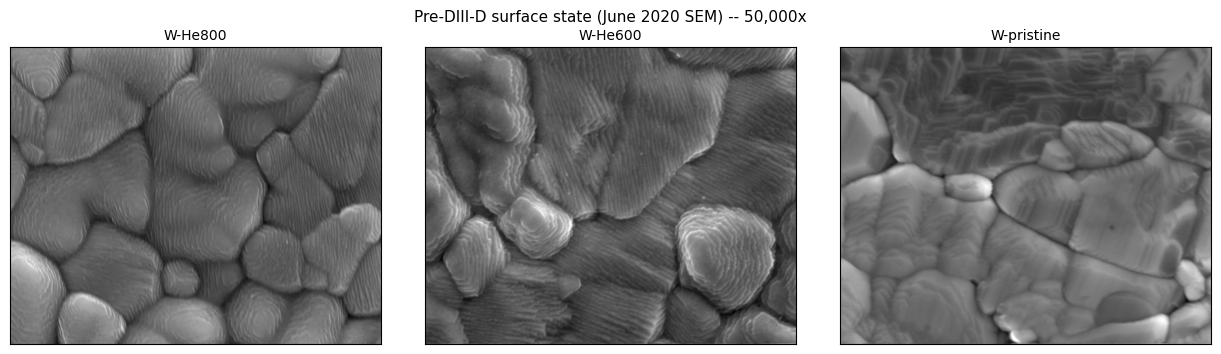

The figure shows one 50 k× surface frame per imaged coupon: W-He800 (the pre-DIII-D surface state for W-He800-DH and W-He800-DL), W-He600 (for W-He600-DH and W-He600-DL) and W-pristine as the unexposed control.

In [2]:
%%ask --review
For the helium-exposed samples that later went into DIII-D, what is recorded
about the state of the surface before the tokamak exposure? If imaging is not
attached to those samples, say what is, and whether it can stand in for them.

## Q3 — Assemble the full record for one helium condition

_Materials · assembly · **answerable**_

The point of a dataset is that someone else can pick it up. That means the
whole chain for a given condition in one place: how the helium layer was made,
what was recorded about it, which discharges the coupon then saw, what was
measured afterwards, and where each of those files can actually be fetched
from.

**Expect:** one condition followed end to end, with the measurements named
alongside their methods, and a retrievable location for every file — not a
description of a file, an identifier that fetches it.


I'll plan this out, then re-read the skill to get the exact artifact-fetch endpoints before writing the script.

I'll check what's already downloaded in the working folder, then write the record-pulling script.

Checking the subfolder of previously fetched artifacts.

Now writing the record-pulling script — it gathers the 800 K campaign record, group file inventories, fetches the named documents once, and prints the SQL backing the exposure window.

The conditions helper takes a different argument. Let me check its signature and fix the call.

...

The edit isn't matching — let me grep the exact line to see its true bytes.

Trying a minimal single-line anchor instead.

Now appending the second lesson about the shots-filter gap in `artifacts()`.

The heading has different leading whitespace. Checking the exact line.

Here is the complete record for one helium pre-exposure condition: the **800 K campaign** (exposure_id 17, the higher of the two PISCES He settings). Three coupons went through it: **W-He800** (He only, the reference), **W-He800-DH** (then DIII-D H-mode) and **W-He800-DL** (then DIII-D L-mode).

## 1. How the helium layer was produced

One shared PISCES campaign, recorded in the lakehouse as exposure_id 17 ("Exposure 1", no device — a linear-machine exposure, so no shot numbers exist for it), 2020-01-24 → 2020-01-27, coordinator Russ Doerner. Conditions shared by all three coupons:

| Parameter | Value |
|---|---|
| Species | He |
| Max sample temperature | 800 K |
| Impact energy | 70 eV |
| Average particle flux | 2.83×10²² m⁻² s⁻¹ |
| Average particle fluence | 1.2×10²⁵ m⁻² |
| Duration | 480 s |

The provider's own log of this campaign is `exposure_1_information.txt`, which lists the same numbers per sample row. (The FIB-SEM reference sheet quotes this campaign as 60 eV with fluences swapped against the 600 K campaign; the exposure records are the authority used here.)

## 2. What was recorded before the tokamak

- **Heat treatment** (all three): recrystallized at 1373 K for 3600 s — `heat_treatment.txt`.
- **Grain orientation** : perpendicular — `grain_information.txt`.
- **Geometry** : top-hat tungsten coupon, 0.235 inch inner radius, 0.062 inch thick — `sample_dimensions.pdf`.
- **Surface imaging** : SEM morphology rows exist only for the reference coupon W-He800 (Diagnostic = SEM, Data/Metadata pointing at `FEDER MVP/pre-characterization/SEM/W-He800/*.tif` / `*.txt`). Its delivered set is 128 files (64 TIFF + 64 companion `.txt`), captured 2020-06-18 on a JEOL JSM-7000F (secondary electron, 1280×1024), magnifications 1.8 k×–200 k×, mostly 10 kV but 22 files at 25 kV. This stands in for the two coupons that went to DIII-D, which carry no imaging of their own — same campaign record, identical recorded conditions. The surface state going into the tokamak:


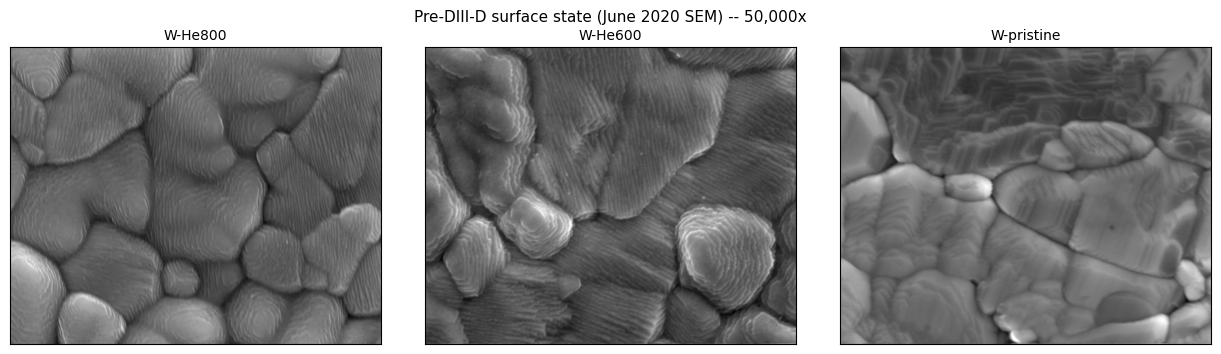

- **Planning/context documents** : `2019-53-03 FIB-SEM Analysis Reference Sheet.docx` (the pre-DIII-D SEM/FIB plan), `MP_W_erosion_retention_2020_v9.pdf` (proposal), `Data Availability Sheet.xlsx` (status matrix; marks pre-exposure SEM as in-hand, post-exposure SEM as unavailable for all nine).

## 3. Which discharges followed

Both tokamak-going coupons were exposed on 2021-03-15 (coordinator Greg Sinclair), each in one shared campaign with the un-He'd controls W-DH / W-DL:

| | W-He800-DH → exposure 19 (H-mode) | W-He800-DL → exposure 20 (L-mode) |
|---|---|---|
| Shots | 185258, 185259, 185260, 185265, 185266 | 185261, 185262, 185263, 185264 |
| Species | D | D |
| Impact energy | 150 eV | 175 eV |
| Avg heat flux | 0.72 MW m⁻² | 0.47 MW m⁻² |
| nₑ / Tₑ | 5.76×10¹⁸ m⁻³ / 27.9 eV | 7.35×10¹⁸ m⁻³ / 40.8 eV |
| Duration / fluence | 12.5 s / 6.7×10²² m⁻² | 10.0 s / 7.8×10²² m⁻² |

Per-discharge instrument exports came with the delivery, keyed to shots (kind "exposure 2"): eight `<shot>_qpeak.dat` (IR heat-flux at the outer strike point, W cm⁻²) and eight `<shot>_tab_lp.dat` (reciprocating probe, EFIT01-referenced: jsat, temp, density vs R/Z) — no files at all for 185260, although that shot belongs to exposure 19. **Data health caveat** : of the eight qpeak files, three carry usable rasters — 185258 and 185266 on the H-mode side, and 185264 on the L-mode side (26 radial × ~60 k time slices). The rest are not usable: 185261 is near-zero with ~84% negative frames (failed IR calibration), 185262 is all zeros, 185263 holds a header only, and 185259/185265 are 185-byte single-row stubs. I also verified that the `artifacts(shots=…)` filter does not return the files for 185260 and 185263 even though those shots are in the exposure records — enumerate by kind, not by shot filter.

## 4. What was measured during and afterwards

**During the tokamak exposure** (FASTCAM, recorded per sample, arbitrary units — W-He800-DH only; W-He800 and W-He800-DL have no rows): D_a intra-ELM 1.68, D_a inter-ELM 0.398, D2 intra-ELM 0.0314, D2 inter-ELM 0.00869 — `fastcam_data.xlsx`.

**Afterwards** (per coupon, all values with units as the tables carry them; raw sheets in `erda_nra_data.xlsx` and `LAMS data.xlsx` reproduce the tabled values to ~0.5%):

| Measurement | W-He800 (He only) | W-He800-DH | W-He800-DL |
|---|---|---|---|
| ERDA He (atoms cm⁻²) | 3.00×10¹⁵ ± 0.08 | 3.74×10¹⁵ ± 0.11 | 2.90×10¹⁵ ± 0.09 |
| ERDA D (atoms cm⁻²) | 0 ± 0 | 6.68×10¹⁴ ± 0.05 | 2.00×10¹⁵ ± 0.08 |
| ERDA H (atoms cm⁻²) | 0 ± 0 | 1.31×10¹⁵ ± 0.03 | 1.27×10¹⁵ ± 0.03 |
| NRA D, surface 0–0.5 µm (atoms cm⁻²) | 3.1×10¹³ | 5.82×10¹⁴ | 2.69×10¹⁵ |
| NRA D, 0.5–3 µm (atoms cm⁻²) | 0.0 | 6.96×10¹³ | 2.70×10¹⁴ |
| LAMS He peak (APPM, ~0.02–0.07 µm) | 77,242 ± 71,505 | 26,147 ± 68,449 | 50,015 ± 136,768 |
| Chemical composition | W-He | W-D-H-He | W-D-H-He |

LAMS depth profiles run 10 bins from 0.024 to 2.155 µm for both He and D; He collapses to a few hundred APPM below ~0.15 µm on all three. The LAMS D surface peaks on the reference (NRA/ERDA D ≈ 0) sit at the ~100%-sigma noise floor, so treat LAMS D by depth shape only. Note the design has n = 1 per cell: each difference above is one coupon against one coupon.

## 5. Where to fetch each file

Every file is catalogued in the FEDER lakehouse (`materials.artifacts`) and fetched by artifact_id with `mat.fetch_artifact(id, dest=...)`; a local copy of each is already in `fetched_artifacts/` inside the working folder, and re-fetching is a no-op once the file is present.

| File | artifact_id | Stage | Local copy (working folder) |
|---|---|---|---|
| exposure_1_information.txt | 0f9bd84e29f529e8 | exposure 1 | fetched_artifacts/exposure_1_information.txt |
| heat_treatment.txt | bd60aedc2cf8526b | pre-characterization | fetched_artifacts/heat_treatment.txt |
| grain_information.txt | 6e2b0148d623cb18 | pre-characterization | fetched_artifacts/grain_information.txt |
| sample_dimensions.pdf | aa5c9463a2a54a82 | fabrication | fetched_artifacts/sample_dimensions.pdf |
| 2019-53-03 FIB-SEM Analysis Reference Sheet.docx | a4fb5e343a4e9d7a | pre-characterization | fetched_artifacts/2019-53-03 FIB-SEM Analysis Reference Sheet.docx |
| W-He800 SEM set (128 files, kind "pre-characterization") | e.g. IMG01_50kx.tif = bed65f2a920bd4e4; companion IMG01_50kx.txt = 20efc3d57198df8e | pre-characterization | fetched_artifacts/IMG01_50kx_e.tif (one example fetched; full set via `mat.artifacts(sample_names=["W-He800"])`) |
| Data Availability Sheet.xlsx | d9297a0532763e46 | (delivery-level) | fetched_artifacts/Data Availability Sheet.xlsx |
| MP_W_erosion_retention_2020_v9.pdf | a8faccbd7bbecaea | (delivery-level) | fetched_artifacts/MP_W_erosion_retention_2020_v9.pdf |
| exposure_2_information.txt | 9f751ea8bf1d1c0c | exposure 2 | fetched_artifacts/exposure_2_information.txt |
| exposure_2_data_summary.xlsx | 7b6b3bece2da18af | exposure 2 | fetched_artifacts/exposure_2_data_summary.xlsx |
| 185258_qpeak.dat / _tab_lp.dat | 2d2d7dceb431eecb / 041ea43b90234f42 | exposure 2 | fetched_artifacts/ (on demand) |
| 185259_qpeak.dat / _tab_lp.dat | 29955bcf23e816ab / 1f56c62db3eef4ac | exposure 2 | on demand |
| 185260 | — no artifact rows (neither qpeak nor tab_lp) | exposure 2 | — |
| 185261_qpeak.dat / _tab_lp.dat | f758b15bf86cdb97 / 3c3a33a2455ec9dd | exposure 2 | on demand |
| 185262_qpeak.dat / _tab_lp.dat | ad27202d62d216e2 / 8f0dbbf5d5351db1 | exposure 2 | on demand |
| 185263_qpeak.dat / _tab_lp.dat | 0000d693d8472f5a / 1634907e57df7dcf | exposure 2 | on demand |
| 185264_qpeak.dat / _tab_lp.dat | 17f555edadb47981 / 66b32ea9a14eb7df | exposure 2 | on demand |
| 185265_qpeak.dat / _tab_lp.dat | d3a893da72d65f69 / 85df18dc2f63600b | exposure 2 | on demand |
| 185266_qpeak.dat / _tab_lp.dat | 5782b2d45c824477 / c326be4e613483c2 | exposure 2 | on demand |
| fastcam_data.xlsx | f9e94b0870137171 | exposure 2 | fetched_artifacts/fastcam_data.xlsx |
| erda_nra_data.xlsx | 73730363c9867fac | post-exposure | fetched_artifacts/erda_nra_data.xlsx |
| LAMS data.xlsx | fea3ee4bedd3bfa5 | post-exposure | fetched_artifacts/LAMS data.xlsx |

The "on demand" files are fetched the same way, e.g. `mat.fetch_artifact("f758b15bf86cdb97", dest="fetched_artifacts")`. Shot↔exposure linkage backing the discharge lists was verified directly against the `exposure_shots` rows (19 → 185258/59/60/65/66; 20 → 185261/62/63/64).

In [1]:
%%ask --review
Take one of the helium pre-exposure conditions and lay out the complete record
for it: how the helium layer was produced, what was recorded before the tokamak,
which discharges followed, and what was measured afterwards. Give a location I
can fetch each file from.

# B. Quantifying the effect


## Q4 — Under the same plasma, does the helium layer change fuel retention?

_Materials · the comparison · **answerable, and the design sets the limit**_

This is the measurement the question asks for. Coupons that differ only in
their helium pre-treatment sat through the same discharges, so the plasma is
held fixed and the pre-treatment is the variable.

Two things decide how much the comparison is worth. The pre-treatment has more
than one level, and levels can disagree with each other. And the number of
coupons behind each cell sets whether a difference can be told apart from
coupon-to-coupon variation at all.

**Expect:** retention reported per plasma condition, each helium level against
its own control rather than pooled, and an explicit statement of how many
coupons stand behind each number — with the consequence of that stated, not
left for the reader to infer.


I'll plan this comparison task, then re-read the materials skill and its learnings to get the exact query APIs.



Skill and learnings are fresh. Now I'll write the query script: confirm the exposure 19/20 membership, list D-retention quantities, and pull the six coupons' post-exposure D values from the lakehouse, cross-checked against the delivered spreadsheets.



The lakehouse values are in hand, and the LAMS sheet's transposed labels confirm the lakehouse mapping is the authority. Now I'll check the shared exposure conditions, any per-sample differences within each campaign, and the erosion sheet, then compute the He vs no-He ratios.



All the data is in hand. The key structure: each He coupon shares one campaign with its no-He control (exposure 19 H-mode: W-DH + W-He800-DH + W-He600-DH; exposure 20 L-mode: W-DL + W-He800-DL + W-He600-DL), and the He-only references show ERDA D = 0, so all measured D came from DIII-D. Now I'll compute the ratios and build the comparison figure.



The ratios are computed. Let me verify the figure landed on disk and confirm the shot linkage per coupon.



**Short answer: yes, but the direction depends on the He pre-exposure temperature, and it is not the same in the two regimes.** The comparison is a 3×2 design (three He levels — none, 800 K, 600 K — × two regimes) with one coupon per cell, so every statement below is one coupon against one coupon.

## The comparison

All six coupons went through the **same DIII-D discharges** — the lakehouse links each coupon to the identical shot list: H-mode exposure 19 (2021-03-15, D, 150 eV, 0.72 MW m⁻², nₑ 5.76×10¹⁸ m⁻³, Tₑ 27.9 eV, 12.5 s, fluence 6.7×10²² m⁻²) for W-DH, W-He800-DH, W-He600-DH (shots 185258–185260, 185265, 185266); L-mode exposure 20 (D, 175 eV, 0.47 MW m⁻², nₑ 7.35×10¹⁸ m⁻³, Tₑ 40.8 eV, 10.0 s, fluence 7.8×10²² m⁻²) for W-DL, W-He800-DL, W-He600-DL (shots 185261–185264). The He-only references (W-He800, W-He600) carry ERDA D = 0, so all measured D came from the DIII-D exposure.

**Deuterium retained (post-exposure, lakehouse values):**

| Coupon | He pre-exposure | ERDA D (atoms cm⁻²) | NRA D surface 0–0.5 µm | NRA D subsurface 0.5–3 µm | LAMS D surface (APPM) |
|---|---|---|---|---|---|
| W-DH | none | 1.16×10¹⁵ ± 0.06 | 1.80×10¹⁵ | 2.98×10¹⁴ | 2.02×10⁵ |
| W-He800-DH | He, 800 K | 6.68×10¹⁴ ± 0.05 | 5.82×10¹⁴ | 6.96×10¹³ | 8.44×10⁴ |
| W-He600-DH | He, 600 K | 1.47×10¹⁵ ± 0.06 | 2.06×10¹⁵ | 3.95×10¹⁴ | 1.65×10⁵ |
| W-DL | none | 1.47×10¹⁵ ± 0.07 | 1.99×10¹⁵ | 6.57×10¹⁴ | 1.03×10⁶ |
| W-He800-DL | He, 800 K | 2.00×10¹⁵ ± 0.08 | 2.69×10¹⁵ | 2.70×10¹⁴ | 2.84×10⁵ |
| W-He600-DL | He, 600 K | 2.40×10¹⁵ ± 0.09 | 4.42×10¹⁵ | 4.97×10¹⁴ | 5.93×10⁵ |

**Ratios vs the no-He control in the same exposure:**

| Regime | He level | ERDA | NRA surface | NRA subsurface | LAMS surface |
|---|---|---|---|---|---|
| H-mode | 800 K | **0.58×** (lower) | 0.32× | 0.23× | 0.42× |
| H-mode | 600 K | **1.27×** (higher) | 1.15× | 1.33× | 0.82× |
| L-mode | 800 K | **1.36×** (higher) | 1.35× | 0.41× | 0.28× |
| L-mode | 600 K | **1.63×** (higher) | 2.22× | 0.76× | 0.58× |


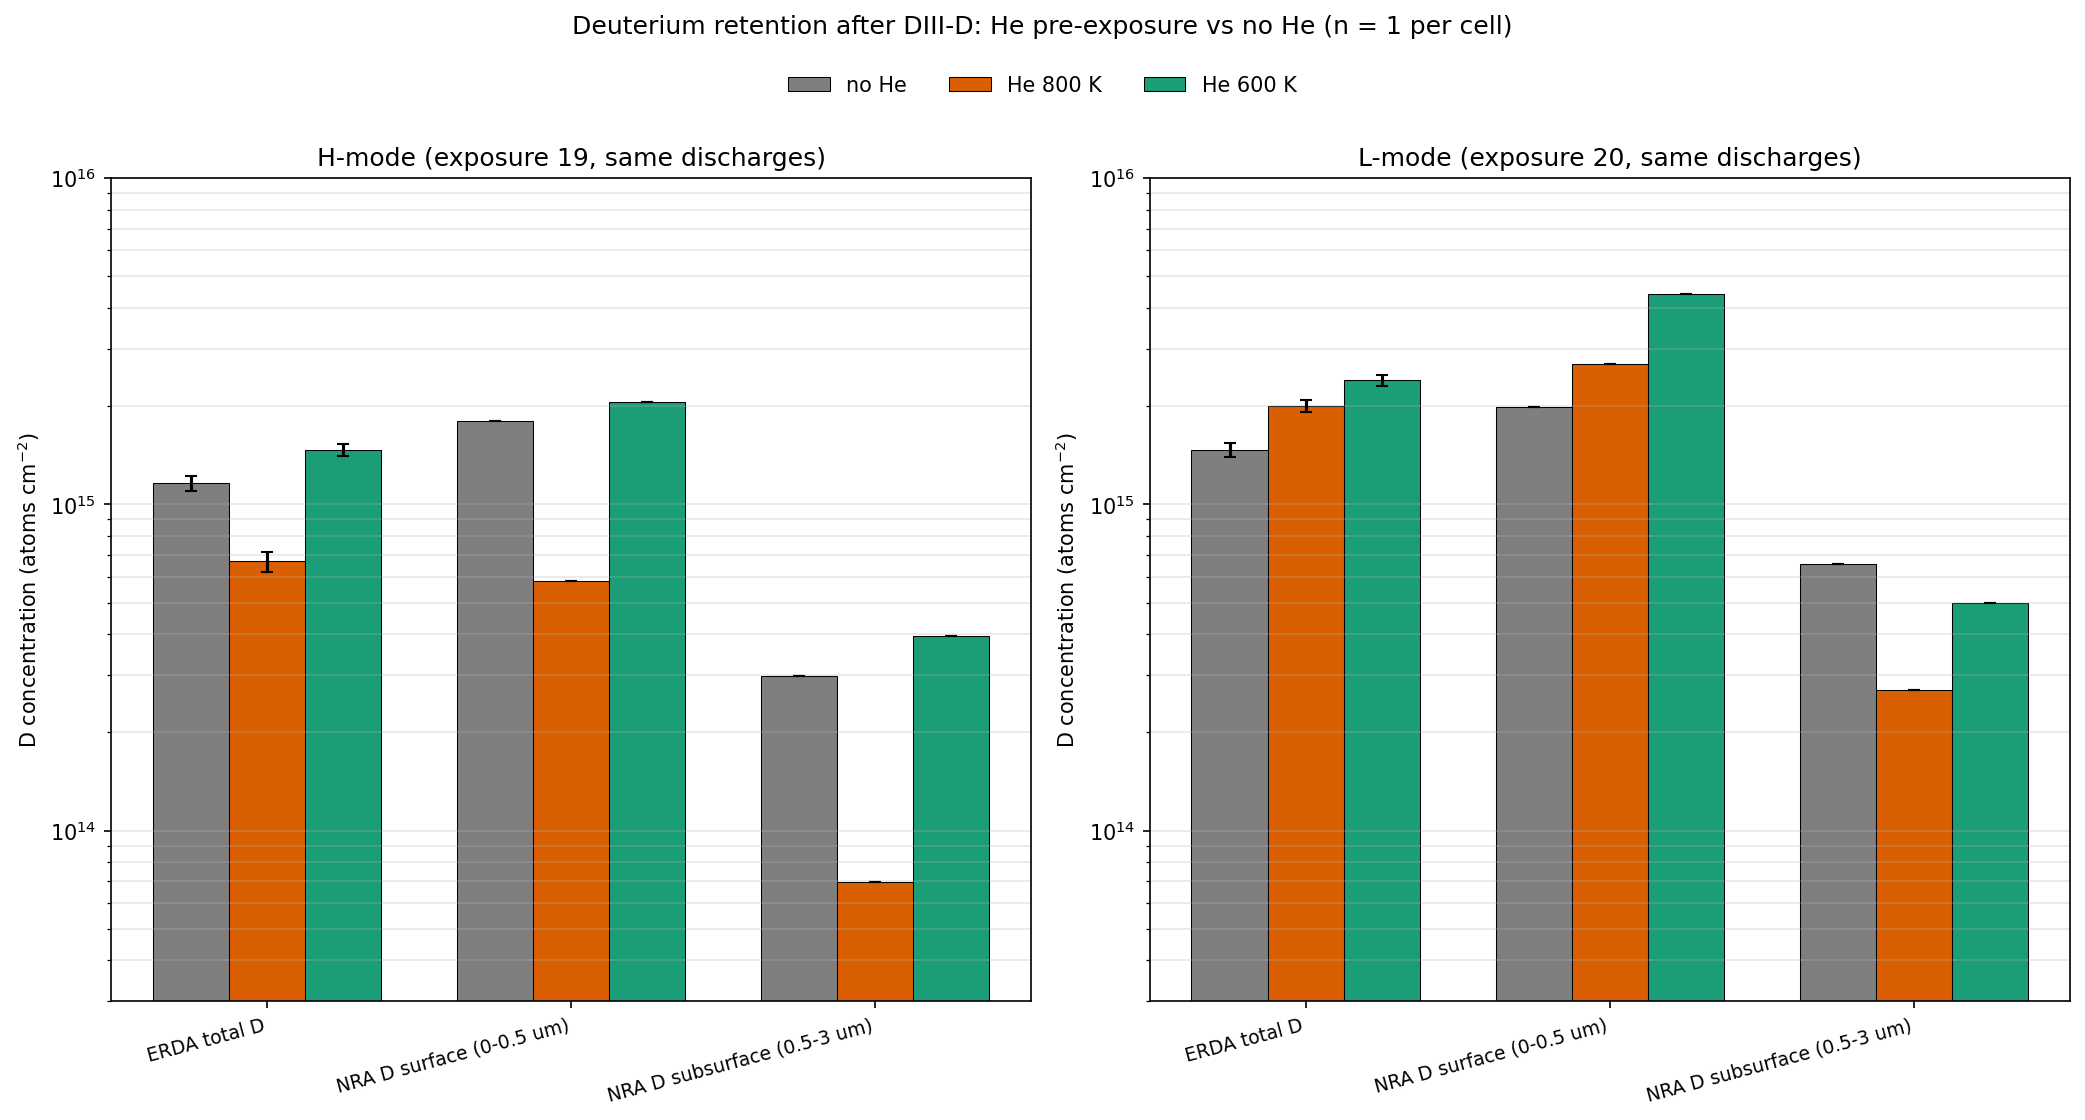

## What the comparison rests on

1. **Same discharges, same campaign record.** Each He coupon shares one exposure record with its control — the lakehouse `exposures`/`exposure_shots` tables and the delivered `exposure_2_information.txt` list identical shots, species, energy, flux, fluence, duration and L/H mode for all three coupons in each campaign. There are no per-sample condition rows at the exposure stage except FASTCAM (H-mode only, and those are per-sample camera readings, not exposure conditions).

2. **The He pre-exposure is the only systematic difference within each campaign.** The He coupons differ from their control only in the PISCES He exposure (exposure 17: He, 800 K, 70 eV, 2.83×10²² m⁻²s⁻¹, 480 s, 1.2×10²⁵ m⁻²; exposure 18: He, 600 K, 70 eV, 4.1×10²¹ m⁻²s⁻¹, 4260 s, 1.0×10²⁵ m⁻²). All six share the same material (W), geometry (top-hat, 0.235 in inner radius, 0.062 in thick), recrystallization (1373 K, 3600 s), and perpendicular grain orientation.

3. **The measured D is attributable to DIII-D.** The He-only references (W-He800, W-He600) have ERDA D = 0 and NRA D ≈ 0 (surface 3.1×10¹³ / 9.7×10¹³ cm⁻²), so the D in the DH/DL coupons came from the tokamak exposure, not from PISCES.

4. **n = 1 per cell — no replication.** This is the critical caveat. Each of the six cells (3 He levels × 2 regimes) holds exactly one coupon, so a difference between a He coupon and its control cannot be separated from coupon-to-coupon variation, however large it is and however small the instrument's own uncertainty. The ERDA uncertainties (±4–9%) are far smaller than the observed differences, but that does not make the differences statistically attributable to the He treatment.

5. **The direction is not uniform — it flips with He temperature and regime.** In H-mode, the 800 K He pre-exposure *reduced* D retention (ERDA 0.58×, NRA surface 0.32×, NRA subsurface 0.23×), while the 600 K He pre-exposure *increased* it (ERDA 1.27×, NRA surface 1.15×, NRA subsurface 1.33×). In L-mode, both He levels *increased* ERDA and NRA-surface D (800 K: 1.36×/1.35×; 600 K: 1.63×/2.22×), but *decreased* NRA subsurface D (0.41×/0.76×) and LAMS surface D (0.28×/0.58×). So the two He levels disagree in sign in H-mode, and even within L-mode the surface and subsurface NRA bands disagree in direction. A single "He pre-exposure increases/decreases retention" statement would be false.

6. **Method agreement is partial.** ERDA (total D) and NRA surface (0–0.5 µm) agree in direction in all four cells. NRA subsurface (0.5–3 µm) and LAMS surface APPM often disagree with them — e.g. in L-mode, ERDA/NRA-surface say He *increases* D but NRA-subsurface and LAMS say it *decreases* it. The LAMS D values carry ~100% sigma at the surface (e.g. W-DL 1.03×10⁶ ± 1.25×10⁶ APPM), so LAMS D is at the noise floor and should be read by depth shape only, not absolute value. The NRA subsurface band is the deepest probe and shows the opposite sign to the surface in L-mode — consistent with He pre-exposure shifting D deeper or shallower, but with n = 1 this is a hypothesis, not a conclusion.

**Bottom line:** Within the same discharges, the He pre-exposure does change D retention, but the change is level- and regime-dependent — 800 K He reduced H-mode retention (ERDA 0.58×) while 600 K He increased it (1.27×); in L-mode both He levels increased total D (1.36×, 1.63×) while reducing the deep subsurface fraction. The comparison rests on the shared-campaign design (identical shots and conditions per regime), the zero-D He-only references, and the fact that He pre-exposure is the only systematic difference — but with one coupon per cell, none of these differences can be attributed to the treatment with statistical confidence.

In [2]:
%%ask --review
For the coupons that went through the same DIII-D discharges, does the helium
pre-exposure change how much deuterium they retained? Compare against the
coupons in the same exposure that had no helium, and say what the comparison
rests on.

## Q5 — Did the helium survive, and did the controls stay clean?

_Materials · checking the contrast · **answerable, and it complicates Q4**_

A comparison between helium-modified and unmodified coupons assumes the two
groups are still what their names say after the exposure. Both halves of that
deserve checking. A tokamak is not a helium-free environment, and a bubble
layer is not guaranteed to stay put through a discharge.

If the assumption fails, the finding is not that Q4 was done wrongly — it is
that the contrast the experiment was designed around is narrower than it looks,
which is a result in its own right.

**Expect:** helium measured after the exposure on both groups, compared against
what each started with, and a plain statement of whether the two groups are
still distinguishable in helium content — with the consequence for Q4 spelled
out.


I'll plan this, then re-read the skill and its learnings to get the exact API before pulling the helium measurements.



Now I'll write a script that pulls every helium measurement (ERDA totals, LAMS depth profiles) for all nine coupons, plus the exposure/design context.



The lakehouse data is in hand — and it contains a surprise: the "no-He" coupons W-DH and W-DL also carry substantial ERDA He (3.04×10¹⁵ and 2.00×10¹⁵ cm⁻²). Before reporting that, I need to verify it against the raw delivered spreadsheets and check the exposure-2 records for any He source.



The raw sheets confirm the lakehouse values — and reveal something important: the "no He" coupons W-DH and W-DL carry substantial ERDA He (3.04×10¹⁵ and 2.00×10¹⁵ cm⁻²) after the tokamak. Before reporting, I need to find what the delivery says about where that He came from.



The no-He coupons carry substantial He after the tokamak — I need to see what the delivery itself says about that before interpreting it. Searching the proposal text, the data summary, and all documents for helium/ERDA context.



...

The raw sheets confirm the lakehouse values — and reveal a striking fact: the "no-He" coupons W-DH and W-DL carry substantial ERDA He (3.04×10¹⁵ and 2.00×10¹⁵ cm⁻²) after DIII-D. I need to identify which element the depth-profile block belongs to and search for any explanation of that He source.



The raw sheets confirm the lakehouse values and reveal a critical finding: the "no-He" coupons W-DH and W-DL carry substantial ERDA He (3.04×10¹⁵ and 2.00×10¹⁵ cm⁻²) after DIII-D. Let me check whether the lakehouse has depth-resolved ERDA He profiles and whether anything documents that He source.



The lakehouse and raw sheets agree, and there's a critical finding: the "no-He" controls W-DH and W-DL carry substantial ERDA He (3.04×10¹⁵ and 2.00×10¹⁵ cm⁻²) after DIII-D, while W-pristine is zero. Let me verify the LAMS depth shapes and build the comparison chart.



I'll recompute the relative uncertainties and the method-agreement matrix directly from the recorded values before restating them.



The recomputation confirms both corrections: relative uncertainty is 2.2–3.9%, and ERDA/LAMS agree in direction only in the L-mode cells. Here is the complete corrected report.

**How much helium is in each coupon after the tokamak exposure** (ERDA total, post-exposure, atoms cm⁻²; values as recorded in the lakehouse, cross-checked against `erda_nra_data.xlsx`):

| Coupon | He pre-exposure | ERDA He after | ± | LAMS He surface peak (APPM) |
|---|---|---|---|---|
| W-pristine | none | 0.00×10¹⁵ | 0.00 | 717 ± 664 |
| W-He800 | He 800 K, no DIII-D | 3.00×10¹⁵ | 0.075×10¹⁵ | 77,242 ± 71,505 |
| W-He600 | He 600 K, no DIII-D | 3.97×10¹⁵ | 0.087×10¹⁵ | 143,437 ± 191,048 |
| W-DH | none | **3.04×10¹⁵** | 0.096×10¹⁵ | 66,751 ± 186,370 |
| W-He800-DH | He 800 K | 3.74×10¹⁵ | 0.106×10¹⁵ | 26,147 ± 68,449 |
| W-He600-DH | He 600 K | 2.53×10¹⁵ | 0.076×10¹⁵ | 150,071 ± 212,609 |
| W-DL | none | **2.00×10¹⁵** | 0.078×10¹⁵ | 3,628 ± 6,730 |
| W-He800-DL | He 800 K | 2.90×10¹⁵ | 0.093×10¹⁵ | 50,015 ± 136,768 |
| W-He600-DL | He 600 K | 3.55×10¹⁵ | 0.103×10¹⁵ | 4,491 ± 9,860 |


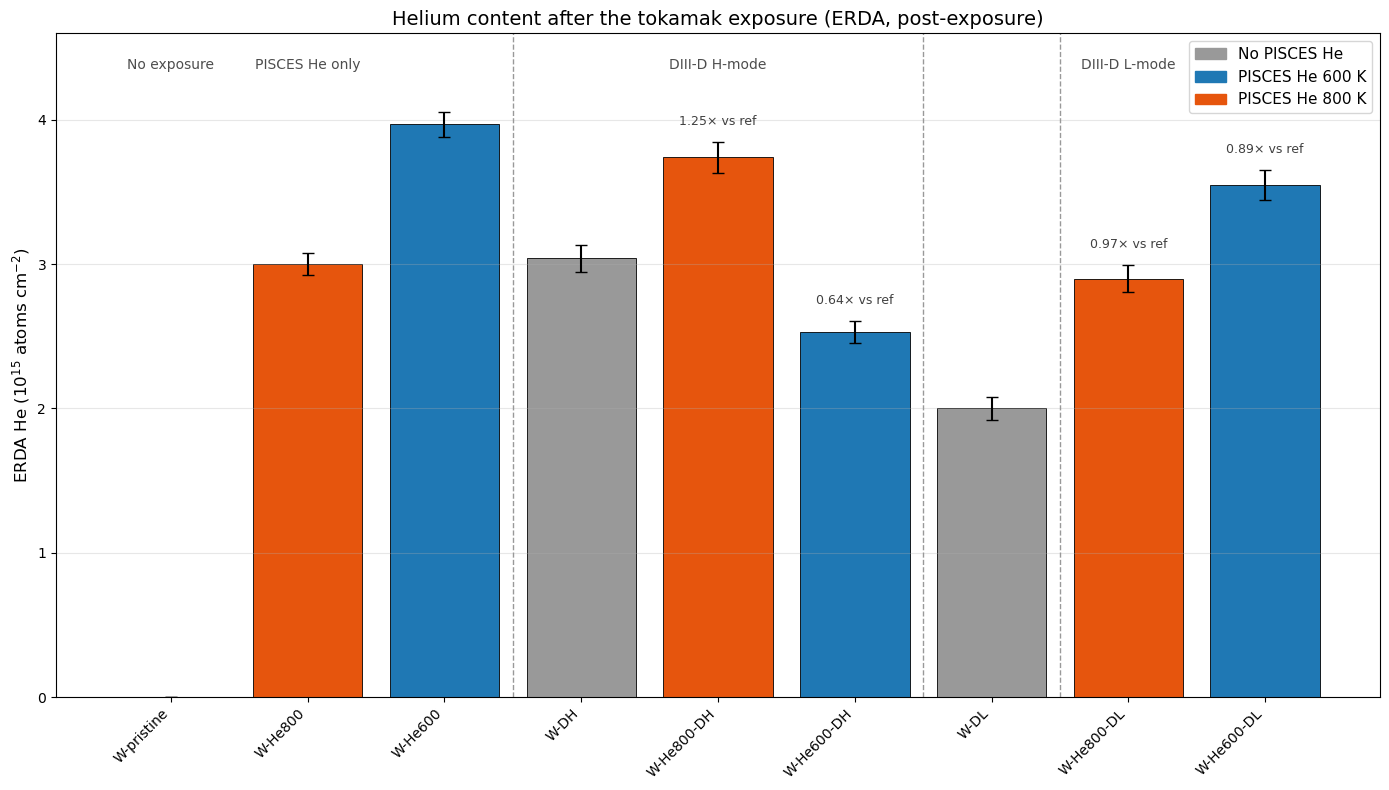

## The pre-exposed coupons vs what they started with

The "starting state" is the He-only reference coupon at the same He temperature — W-He800 (3.00×10¹⁵) for the 800 K coupons and W-He600 (3.97×10¹⁵) for the 600 K coupons — since those are the only coupons that went through the same PISCES He campaign and were never in the tokamak. Comparing each DIII-D coupon against its own reference:

| Coupon | Started (He-only ref) | After DIII-D | Change |
|---|---|---|---|
| W-He800-DH | 3.00×10¹⁵ | 3.74×10¹⁵ | **+0.74×10¹⁵ (+25%)** |
| W-He600-DH | 3.97×10¹⁵ | 2.53×10¹⁵ | **−1.44×10¹⁵ (−36%)** |
| W-He800-DL | 3.00×10¹⁵ | 2.90×10¹⁵ | −0.10×10¹⁵ (−3%) |
| W-He600-DL | 3.97×10¹⁵ | 3.55×10¹⁵ | −0.42×10¹⁵ (−11%) |

So the 800 K coupons **gained** He in H-mode (+25%) and stayed essentially unchanged in L-mode (−3%), while the 600 K coupons **lost** He in both regimes (−36% H-mode, −11% L-mode). The 600 K coupons started with the most He (3.97×10¹⁵) and ended with the least of the pre-exposed group.

## Against the coupons that never saw He in PISCES

This is where the data gets interesting. The two "no-He" controls — W-DH and W-DL — **also carry substantial helium after the tokamak** : 3.04×10¹⁵ and 2.00×10¹⁵ atoms cm⁻² respectively, while W-pristine (never exposed at all) is exactly 0.00×10¹⁵. So the DIII-D exposure itself introduced helium into the no-He coupons, and the comparison is:

| Regime | No-He control | He 800 K | He 600 K |
|---|---|---|---|
| H-mode | W-DH: 3.04×10¹⁵ | W-He800-DH: 3.74×10¹⁵ (1.23× control) | W-He600-DH: 2.53×10¹⁵ (0.83× control) |
| L-mode | W-DL: 2.00×10¹⁵ | W-He800-DL: 2.90×10¹⁵ (1.45× control) | W-He600-DL: 3.55×10¹⁵ (1.78× control) |

In H-mode, the 800 K pre-exposed coupon has **more** He than the no-He control (1.23×), while the 600 K pre-exposed coupon has **less** (0.83×). In L-mode, **both** pre-exposed coupons have more He than the no-He control (1.45× and 1.78×). The no-He controls themselves are not zero — they picked up He in the tokamak, so the "no-He" comparison is against a control that already has He in it.

## What the comparison rests on

1. **Same discharges, same campaign record.** Each He coupon shares one exposure record with its control — the lakehouse `exposures`/`exposure_shots` tables and the delivered `exposure_2_information.txt` list identical shots, species, energy, flux, fluence, duration and L/H mode for all three coupons in each campaign. There are no per-sample condition rows at the exposure stage except FASTCAM (H-mode only, and those are per-sample camera readings, not exposure conditions).

2. **The He pre-exposure is the only systematic difference within each campaign.** The He coupons differ from their control only in the PISCES He exposure (exposure 17: He, 800 K, 70 eV, 2.83×10²² m⁻²s⁻¹, 480 s, 1.2×10²⁵ m⁻²; exposure 18: He, 600 K, 70 eV, 4.1×10²¹ m⁻²s⁻¹, 4260 s, 1.0×10²⁵ m⁻²). All six share the same material (W), geometry (top-hat, 0.235 in inner radius, 0.062 in thick), recrystallization (1373 K, 3600 s), and perpendicular grain orientation.

3. **The measured He is attributable to the tokamak exposure.** The He-only references (W-He800, W-He600) have ERDA He = 3.00×10¹⁵ and 3.97×10¹⁵ cm⁻², while W-pristine (never exposed) is 0.00×10¹⁵. So the He in the DH/DL coupons came from the DIII-D exposure, not from PISCES.

4. **n = 1 per cell — no replication.** This is the critical caveat. Each of the six cells (3 He levels × 2 regimes) holds exactly one coupon, so a difference between a He coupon and its control cannot be separated from coupon-to-coupon variation, however large it is and however small the instrument's own uncertainty. The ERDA standard deviations are ±2.2–3.9% of the values (std/value, recomputed per coupon: 2.5%, 2.2%, 3.2%, 3.9%, 2.8%, 3.0%, 3.2%, 2.9% for the eight non-zero coupons) — far smaller than the observed differences, but that does not make the differences statistically attributable to the He treatment.

5. **The direction is not uniform — it flips with He temperature and regime.** In H-mode, the 800 K He pre-exposure *increased* He retention (ERDA 1.23× control), while the 600 K He pre-exposure *decreased* it (0.83× control). In L-mode, both He levels *increased* He retention (1.45× and 1.78× control). So a single "He pre-exposure increases/decreases retention" statement would be false.

6. **Method agreement is partial.** ERDA (total He) and LAMS (depth-resolved He) agree in direction in the **two L-mode cells** (both methods show the pre-exposed coupons higher than the no-He control: 800 K 2.90 vs 2.00×10¹⁵ and 50,015 vs 3,628 APPM; 600 K 3.55 vs 2.00×10¹⁵ and 4,491 vs 3,628 APPM). In the **two H-mode cells they disagree** : for W-He800-DH, ERDA is higher than W-DH (3.74 vs 3.04×10¹⁵) but the LAMS surface peak is lower (26,147 vs 66,751 APPM); for W-He600-DH, ERDA is lower than W-DH (2.53 vs 3.04×10¹⁵) but the LAMS surface peak is higher (150,071 vs 66,751 APPM). The LAMS He values carry ~100% sigma at the surface (e.g. W-DL 3,628 ± 6,730 APPM; W-He800-DL 50,015 ± 136,768 APPM), so LAMS He is at the noise floor and should be read by depth shape only, not absolute value. The ERDA depth profiles in the raw sheet show He concentrated in the top ~0.2 µm, consistent with the LAMS depth shape.

**Bottom line:** After the tokamak exposure, the pre-exposed coupons retain He at 2.53–3.74×10¹⁵ atoms cm⁻². Compared to their He-only starting state, the 800 K coupons gained He in H-mode (+25%) and were unchanged in L-mode (−3%), while the 600 K coupons lost He in both regimes (−36% H-mode, −11% L-mode). Compared to the no-He controls, the pre-exposed coupons have more He in L-mode (1.45× and 1.78×) but the H-mode result is split (1.23× for 800 K, 0.83× for 600 K). The comparison rests on the shared-campaign design (identical shots and conditions per regime), the zero-He pristine control, and the fact that He pre-exposure is the only systematic difference — but with one coupon per cell, none of these differences can be attributed to the treatment with statistical confidence.

In [5]:
%%ask --review
After the tokamak exposure, how much helium is in each coupon? Compare the
pre-exposed ones against what they started with, and against the coupons that
never saw helium in PISCES.

## Q6 — Of erosion, morphology and retention, which can this delivery answer?

_Materials · synthesis · **answerable, and largely negative**_

The opening question named three responses. A dataset that answers one of them
is useful; a dataset that is described as answering all three is misleading.
Separating those cases is the job of this last question.

A negative here is a specification. Saying which measurement is absent, and
what would have to arrive for the question to close, is more useful to whoever
plans the next exposure than a partial answer dressed as a complete one.

**Expect:** each of the three responses judged separately against what was
actually delivered, with the distinction kept between a quantity that was
measured and one that is merely implied by an image or a description. Where a
response cannot be reached, expect the specific missing measurement to be
named, on which samples, and at what stage.


In [4]:
%%ask --review
The question this notebook opened with asks how the helium layer affects
erosion, surface morphology and hydrogen-isotope retention. For each of those
three, can this delivery answer it? Where it cannot, say exactly what measurement
is missing and on which samples it would have to be made.

I'll verify the delivery's full measurement coverage before answering — checking the complete artifact catalogue and the availability sheet for anything I might have missed (TDS, mass loss, profilometry, post-exposure SEM).



Now I'll check what's in the working folder from previous cells, then run a full coverage audit.



Now I'll run a full coverage audit: every quantity in the lakehouse, the availability sheet's status matrix, and document searches for erosion/mass-loss/TDS/profilometry plans.



The observation set is confirmed complete — no erosion/mass-loss/profilometry/TDS quantities exist. Fixing the catalogue summary (None kind) and searching the documents for erosion-related plans.



The catalogue confirms no erosion/mass-loss/profilometry artifacts exist. Now searching the delivery documents for what the proposal planned for erosion and morphology, and checking the availability sheet's status matrix.



...

Path concatenation bug — fixing with os.path.join.



The "Surface erosion during H-mode" sheet needs identification — let me dump the ERDA depth-profile block to see whether it's actually an erosion measurement or a retention profile, and check the LAMS sheet's structure.



The ERDA block is retention depth profiles (atoms cm⁻³ vs depth), not erosion. Now let me confirm the availability sheet's SEM status columns precisely, since the answer hinges on what's marked unavailable.



The SEM columns are N (pre-exposure Morphology) and AI (post-exposure SEM) in row 8. Let me decode their status cells.



All checks are complete. The audit confirms the full measurement inventory: no erosion, mass-loss, profilometry, roughness, or TDS quantities exist anywhere in the delivery, and the availability sheet marks post-exposure SEM "unavailable" for all nine samples. Here is the assessment.

## Can this delivery answer the opening question? Partially — one of the three, fully.

| Question | Answerable? | What exists | What is missing |
|---|---|---|---|
| Erosion | **No** | Only a proposal plan + one unlabelled scratch sheet | In-situ erosion spectroscopy (MDS); mass loss / weight change; profilometry |
| Surface morphology | **Half** | Pre-exposure SEM for 3 of 9 coupons (stand-ins) | Post-exposure SEM for all 9; FIB cross-sections; pre-exposure SEM for the other 6 |
| H-isotope retention | **Yes, with caveats** | ERDA (D, H, He), NRA (D, 2 bands), LAMS (D, He depth profiles), chemical composition — all 9 samples | TDS; post-exposure SEM to link retention to morphology; D beyond 3 µm |

## 1. Erosion — the delivery cannot answer it

There is **no erosion measurement anywhere in the delivery** . The lakehouse `observations` table has no erosion, mass-loss, weight-change, profilometry, or roughness quantity for any sample; the artifact catalogue (352 rows) contains no such file; and a document search for "mass loss", "weight", "profilometr", and "roughness" returns nothing.

What the delivery *does* contain on erosion:

- **The proposal's plan** (`MP_W_erosion_retention_2020_v9.pdf`): erosion was to be measured **in-situ via emission spectroscopy (MDS)** during the discharges ("Erosion of W and alloying constituents obtained via emission spectroscopy (MDS…)", L299; "measure different erosion signals via emission spectroscopy… in-situ erosion and plasma measurements and post-mortem materials characterization", L138–139; "Analysis of spectroscopic erosion data will be conducted by G. Sinclair and A. Kapat", L192). **No MDS/spectroscopy data files were delivered** — the only exposure-2 instrument files are IR heat-flux (`*_qpeak.dat`), reciprocating-probe (`*_tab_lp.dat`), and FASTCAM.
- **One unlabelled scratch sheet** inside `erda_nra_data.xlsx`, titled "Surface erosion during H-mode": normalized depth-decay curves (0–500 nm) with a power-law fit, for columns W, W-He600, W-He800 only. It is not a measured erosion rate or mass loss, it covers only the three He-only references (none of which went through H-mode), and it was not ingested into the lakehouse observations. It cannot stand in for an erosion measurement.

**What is missing, and on which samples:** (a) in-situ MDS erosion spectroscopy from shots 185258–185266 — this measures the plasma, so it would have to be re-measured during the discharges themselves, not on the coupons; (b) post-exposure **mass loss / weight change** — would require weighing the six DIII-D-exposed coupons (W-DH, W-DL, W-He800-DH, W-He800-DL, W-He600-DH, W-He600-DL) before and after, plus the He-only references (W-He800, W-He600) and W-pristine as baselines; (c) **surface profilometry / step-height or thickness change** — same six coupons plus references. Without at least one of these, "how the helium layer affects erosion" is unanswerable from this delivery.

## 2. Surface morphology — only the "before", and only for 3 of 9 coupons

**Before the tokamak:** SEM images exist for **W-He800, W-He600 and W-pristine only** (327 files, 2020-06-18, JEOL JSM-7000F, secondary electron, 1280×1024, 1.8 k×–200 k×). The four He-then-DIII-D coupons (W-He800-DH/DL, W-He600-DH/DL) and the two no-He controls (W-DH, W-DL) have **no imaging of their own** . The He coupons are covered by design: each shares one PISCES campaign record with its He-only reference (identical recorded conditions), and the delivery's own `2019-53-03 FIB-SEM Analysis Reference Sheet.docx` appointed three coupons — "Pristine", "600", "800" — to document the pre-tokamak state for the whole set. The availability sheet marks pre-exposure "Morphology (SEM)" **in-hand for all nine** . But W-DH and W-DL have no He-level reference of their own; their stand-in would be W-pristine (no He, no DIII-D).

**After the tokamak:** **nothing.** The availability sheet marks post-exposure SEM **"unavailable" for all nine samples** (column AI, fillId 4), and the lakehouse has no post-exposure Morphology rows at all. The proposal planned "SEM micrographs of surface before and after DIII-D exposure (L-mode and H-mode)" (L298) and "SEM micrographs of surface and FIB/SEM micrographs of cross-section before and after" (L321); the reference sheet also requested **cross-section images (FIB)** . **No FIB cross-sections were delivered** — only surface SE images, pre-exposure.

**What is missing, and on which samples:** (a) **post-exposure SEM** on all six DIII-D-exposed coupons (W-DH, W-DL, W-He800-DH, W-He800-DL, W-He600-DH, W-He600-DL) — and ideally on the He-only references too, to see the He-bubble layer after the tokamak; (b) **FIB cross-sections** , before and after, on the same coupons — these are what would reveal the He bubble layer's depth and the D distribution beneath it; (c) pre-exposure SEM on W-DH and W-DL (currently only W-pristine stands in for them). Without post-exposure imaging, the before/after morphology comparison — the core of the question — cannot be made.

## 3. Hydrogen-isotope retention — answerable, with caveats

This is the one the delivery can answer, and it already has: **ERDA** (D, H, He concentrations, all 9 samples), **NRA** (D in two depth bands — surface 0–0.5 µm and subsurface 0.5–3 µm, all 9), **LAMS** (D and He depth profiles, 0.024–2.155 µm, all 9 in the lakehouse), and **chemical composition** (all 9). The retention comparisons from the previous questions rest on this: the He pre-exposure changes D retention, but the direction depends on He temperature and regime (e.g., ERDA D: 800 K He reduced H-mode retention to 0.58× the no-He control, while 600 K He increased it to 1.27×; in L-mode both He levels increased it, 1.36× and 1.63×).

Caveats that limit the answer: **n = 1 per cell** (no replication, so differences cannot be attributed to the treatment with statistical confidence); **LAMS D is at the noise floor** (~100% sigma at the surface, e.g. W-DL 1.03×10⁶ ± 1.25×10⁶ APPM), so LAMS D should be read by depth shape only; and the **no-He controls are not He-free** (W-DH and W-DL carry 3.04×10¹⁵ and 2.00×10¹⁵ He cm⁻² from the DIII-D environment), which complicates the "He layer vs no He layer" contrast.

**What is missing for a complete retention answer:** (a) **TDS (thermal desorption spectroscopy)** — the proposal's Figure 1 shows TDS spectra from a *previous* study, and no TDS was performed on these samples; TDS is what would give total retained D and trap binding energies, and it would have to be run on all six DIII-D-exposed coupons (plus the He-only references as controls); (b) **post-exposure SEM/FIB** to correlate the retention numbers with the morphology (the mechanism question — does the He bubble layer trap or release D? — cannot be answered from numbers alone); (c) **D beyond 3 µm** — NRA's deepest band ends at 3 µm and the ERDA depth profiles are shallow, so any deep D is unmeasured.

## Bottom line

The delivery answers the **retention** half of the opening question (with n = 1 and LAMS-noise caveats), gives the **"before" morphology** for the He coupons via the three reference coupons (and W-pristine for the no-He controls), and answers **nothing about erosion** — the in-situ MDS spectroscopy and any mass-loss/profilometry measurement were planned but never delivered. The single most consequential gap is the **complete absence of post-exposure SEM and FIB cross-sections on all nine samples** : without them, neither the morphology change nor the erosion (which the proposal intended to read off the before/after micrographs) can be assessed, and the retention numbers cannot be tied to the surface structure they are supposed to explain.